# Exploratory Data Analysis

In [ ]:
# Environment set-up an data loading

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/Teen_Mental_Health_Dataset (1).csv")

In [ ]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
df.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [ ]:
# Structural Inspection

In [ ]:
df.describe().T


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [ ]:
df.shape

(1200, 13)

In [ ]:
df.columns


Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [ ]:
# Data Cleaning (The Preprocessing Phase)

In [ ]:
# Duplicate Handling

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# No duplicate values

In [ ]:
# Missing Value Analysis (next cell)

In [ ]:
df.isnull().sum()


,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [ ]:
# We have 891 rows. Out of that, only Embarked, Age and Cabin have null values. However, the number of null values in both Age aand Cabin the columns are not small enough to use "df.dropna()". Hence, we don't drop Age and Cabin. We only drop Embarked

In [ ]:
# printing the same for better format

In [ ]:
print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [ ]:
# dropping Embarked
df = df.dropna(subset=["Embarked"])

In [ ]:
# We need to replace null values with the mode of the respective column

In [ ]:
print(df['Age'].value_counts())

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64


In [ ]:
# 24 is the mode value for Age column.(Frequency = 30)

In [ ]:
# using mode to replace missing value
df['Age'] = df['Age'].fillna(df['Age'].mode()[0])

In [ ]:
# do the same for "Cabin" column
print(df['Cabin'].value_counts())

Cabin
C23 C25 C27    4
G6             4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 146, dtype: int64


In [ ]:
# We use the first mode value to replace null values although we have three mode values
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

In [ ]:
# Verify
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
num_cols = df.select_dtypes( include = ['int64', 'float64']).columns
num_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [ ]:
cat_cols = df.select_dtypes( include = ['object', 'category']).columns
cat_cols

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [ ]:
# Datatype Correction


array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

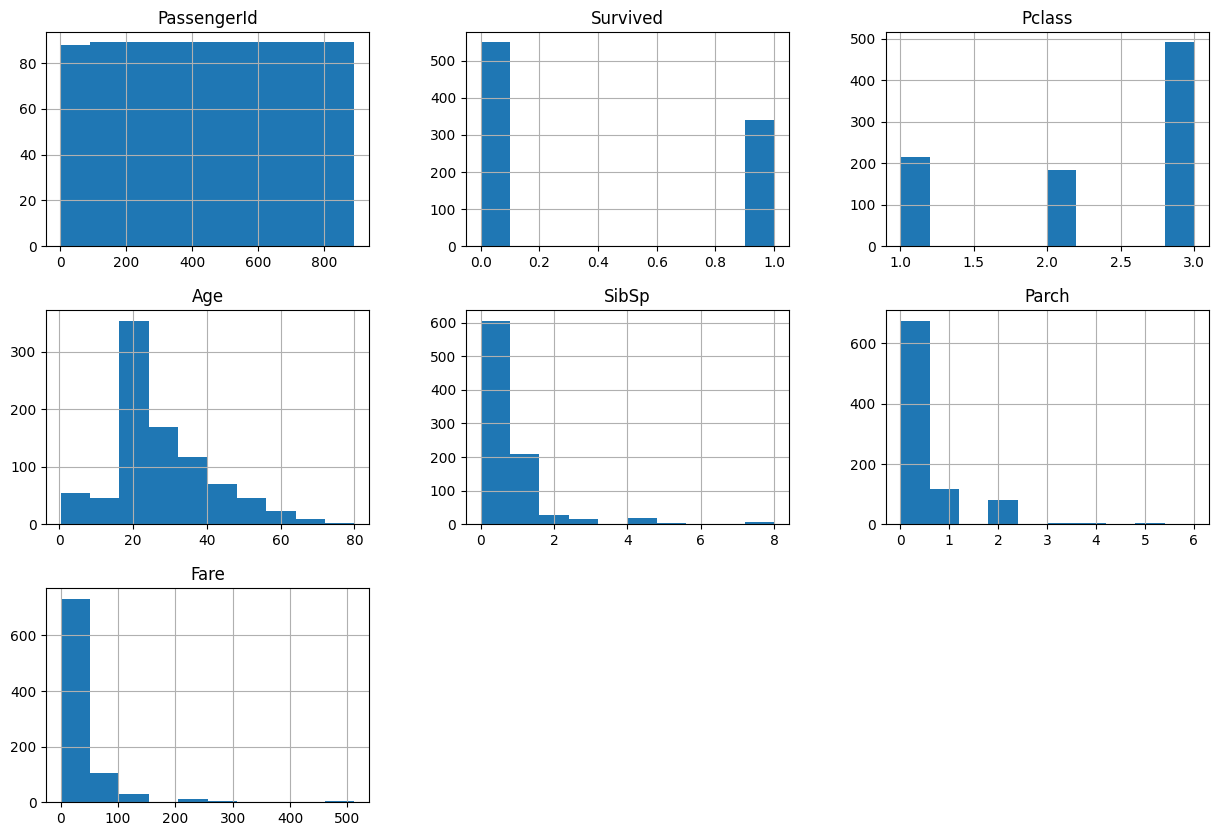

In [ ]:
# Unvivariate Analysis
df.hist(figsize=(15, 10), layout=(3,3))

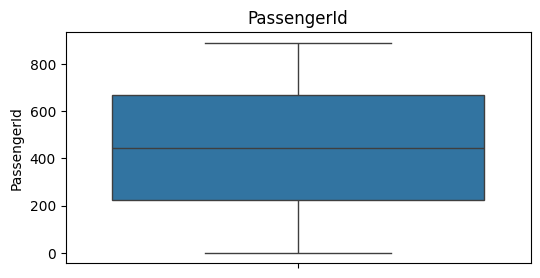

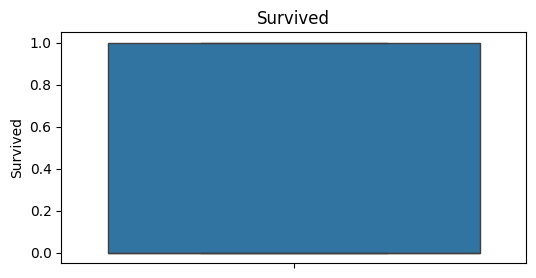

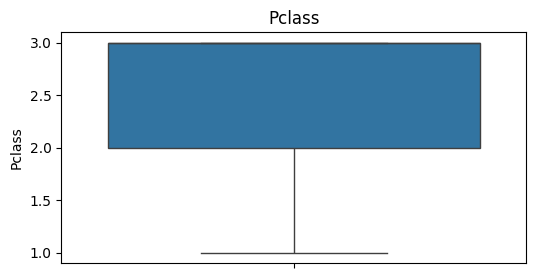

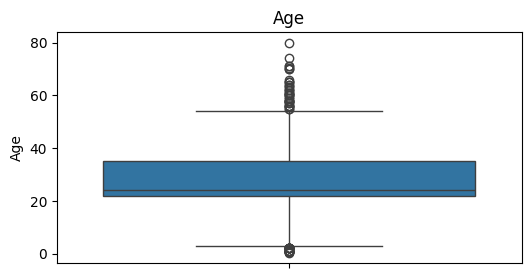

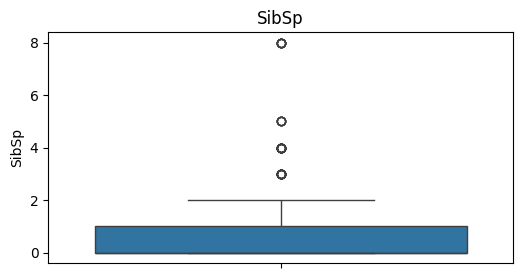

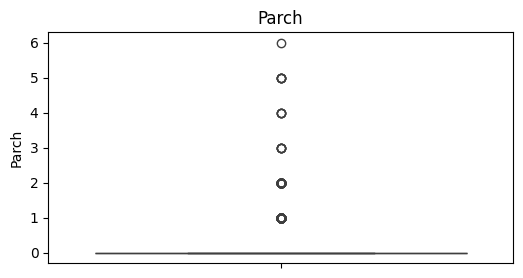

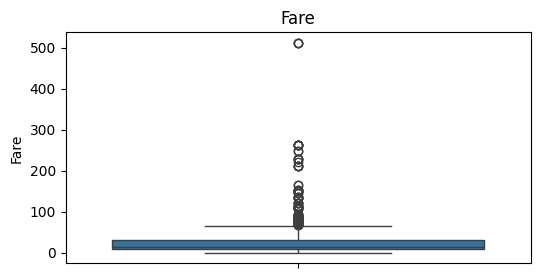

In [ ]:
# Box Plot
for col in num_cols:
  plt.figure( figsize = (6, 3))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [ ]:
'''The box plot analysis performed on numerical features—specifically Age, Fare, SibSp,
and Parch—revealed the distribution and presence of extreme values within the dataset.

Fare & Age: The plots identified significant outliers, particularly in the Fare column.
These represent 1st-class passengers paying premium prices, which is a critical feature for the survival model.
These values are genuine and not data errors, so they should be retained.

SibSp & Parch: The distribution is heavily right-skewed, reflecting that the vast majority
of passengers traveled either alone or with a single family member.

Conclusion: The presence of these outliers suggests that while the data is generally clean,
feature scaling or transformations (such as log transformation for Fare) may be necessary
before model training to prevent extreme values from disproportionately influencing the results.'''

SyntaxError: unterminated triple-quoted string literal (detected at line 1) (437671285.py, line 1)

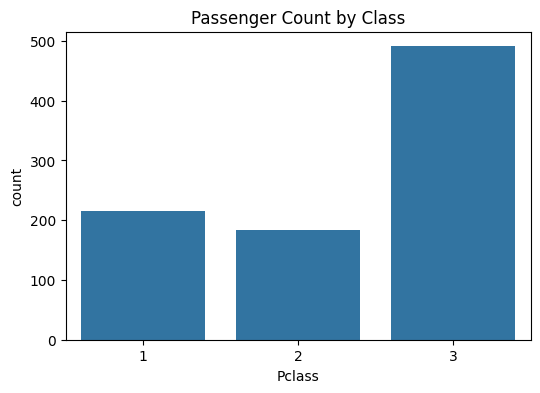

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Count by Class')
plt.show()

In [ ]:
print(df['Pclass'].value_counts())

Pclass
3    491
1    214
2    184
Name: count, dtype: int64


In [ ]:
# Shows that about 55% of passengers were in 3rd class, etc.
print(df['Pclass'].value_counts(normalize=True))

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64


In [ ]:
numeric_df = df[num_cols]

In [ ]:
corr_matrix = numeric_df.corr()

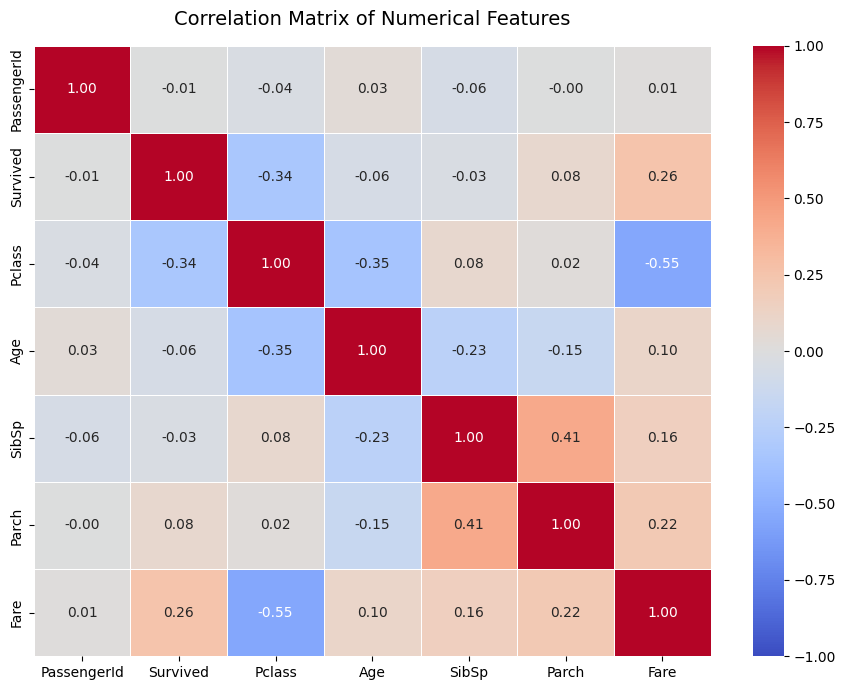

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

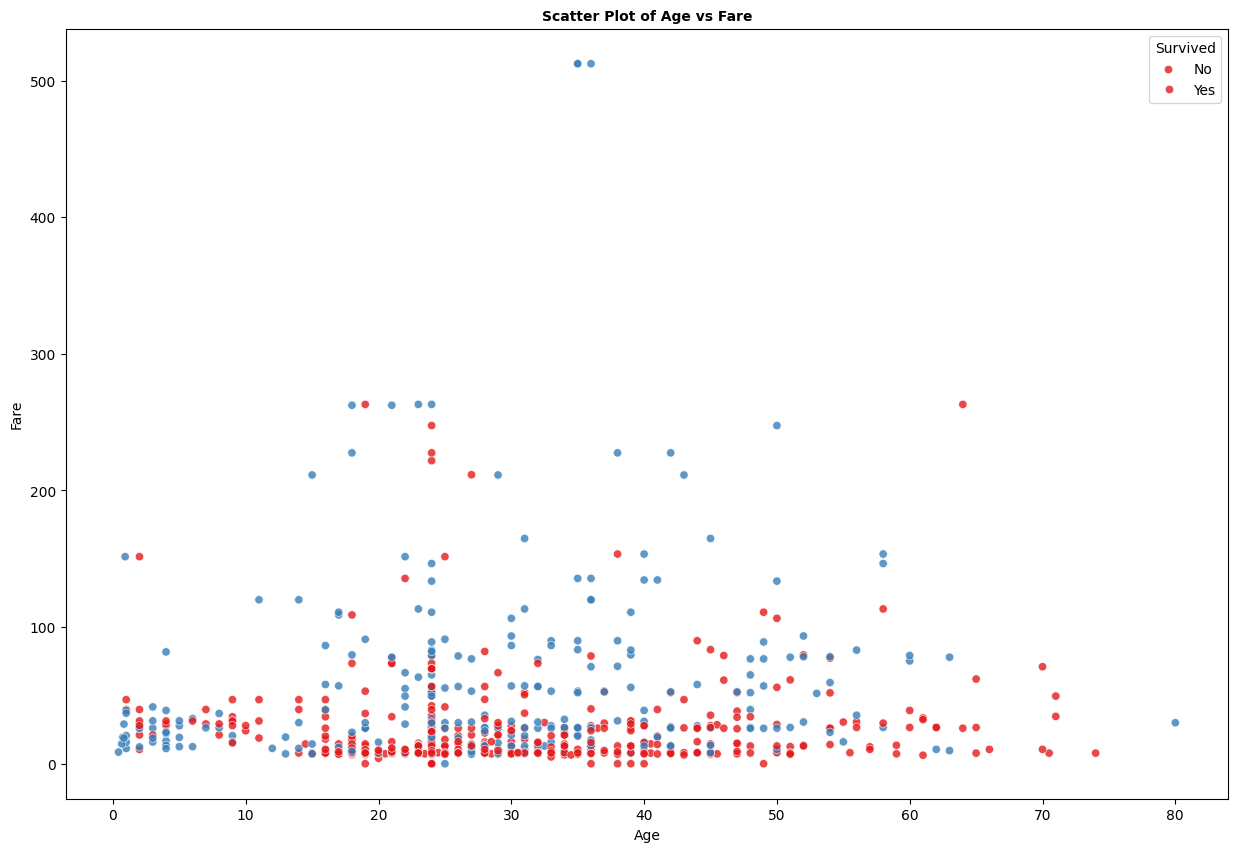

In [ ]:
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'Age', y = 'Fare', hue = 'Survived', data = df, palette = 'Set1', alpha = 0.8)

plt.title("Scatter Plot of Age vs Fare", fontsize = 10, fontweight = 'bold')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title = 'Survived', labels = ['No', 'Yes'])
plt.show()

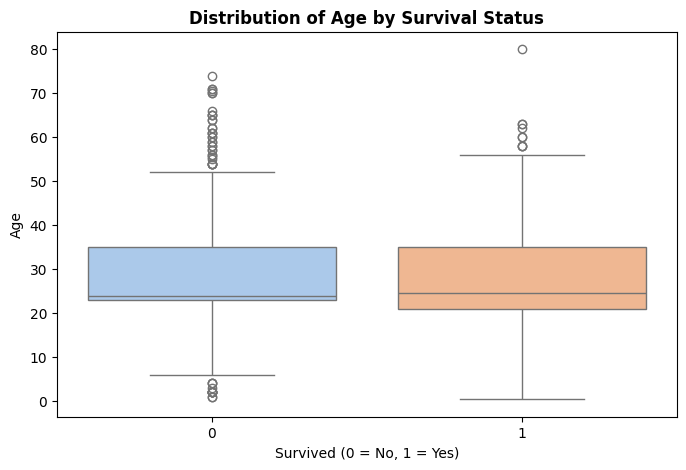

In [ ]:
plt.figure(figsize = (8, 5))
sns.boxplot(x = 'Survived', y = 'Age', data = df, palette = 'pastel')
plt.title('Distribution of Age by Survival Status', fontsize = 12, fontweight = 'bold')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

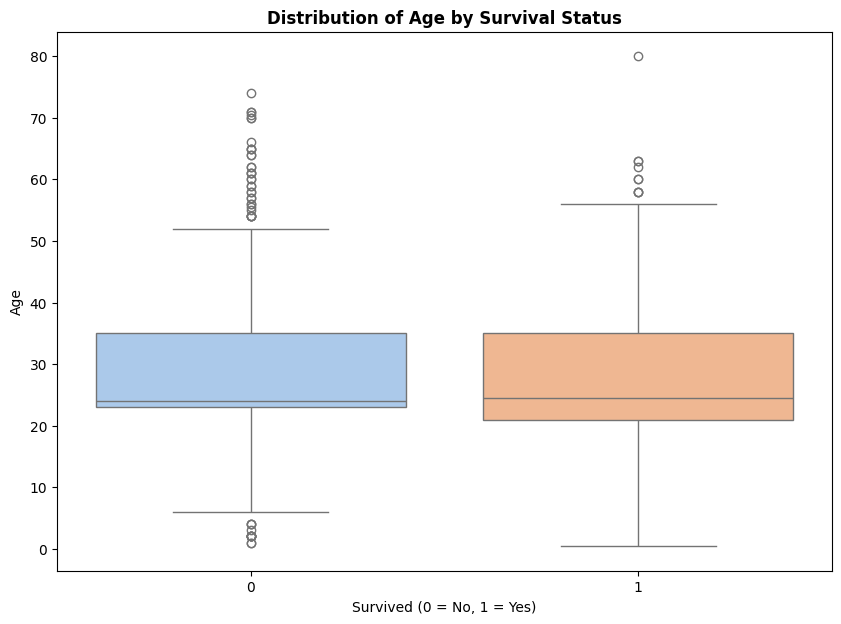

In [ ]:
plt.figure(figsize = (10, 7))
sns.boxplot(x ='Survived', y = 'Age', data = df, palette = 'pastel')
plt.title('Distribution of Age by Survival Status', fontsize = 12, fontweight = 'bold')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

In [ ]:
'''Summary

1. Class Bias: Upper-class status and higher ticket fares heavily favored survival.
2. Family Clustering: High correlation between family metrics reveals passengers traveled together.
3. Age Invariance: Median age profiles remained similar regardless of survival.

Model Readiness:
The data is not model-ready. Text features (`Sex`, `Embarked`) need categorical encoding, while skewed
columns like `Fare` require scaling to prevent outlier distortion. Finally, uninformative identifiers
like `Name` and `Ticket` must be dropped before model training (unless you find a relation in name patterns and trends).

Categorical encoding is the process of converting non-numerical, text-based labels
(like colors or job titles) into numerical values'''